In [1]:
%run utilities_general.ipynb 
%run utilities_DIRKs_and_PIRKs.ipynb
load_standard_packages()
change_wordir()
import json
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import math
from scipy.signal import savgol_filter

C:\Users\andre\AppData\Local\Temp\ipykernel_30956\1467589274.py:1: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  from scipy import interpolate
Could not find cannot import name 'dopri5' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'rodas' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'odassl' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find ODEPACK functions.
Could not find RADAR5
Could not find GLIMDA.


1.58.0


In [2]:
model = "with_dpsi"
# model = "latest_dev"
m = load_model(model)

colors, colours = colourblind_palette("own")


succesfully loaded with_dpsi :D


In [3]:
# file_name = "DIRK_ECS_20250623_Norway_Maple_50-50000.json"
# file_name = "DIRK_ECS_20250624_Cercis_siliquastrum_50-50000.json"
# file_name = "DIRK_ECS_20250624_Neillia_50-50000.json"
# file_name1 = "DIRK_ECS_20250805_Ocimum_basilicum.json"
# file_name2 = "DIRK_ECS_20250805_Petroselinum_crispum.json"

# file_name = "DIRK_P700_20250709_Loewenzahn_30-2000.json"
file_name1 = "DIRK_P700_20250805_Ocimum_basilicum.json"
file_name2 = "DIRK_P700_20250805_Petroselinum_crispum.json"

# file_name = "templ.json"

with open("data/" +file_name1, 'r') as file:
    json_data1 = json.load(file)

with open("data/" +file_name2, 'r') as file:
    json_data2 = json.load(file)

## analyse the measurements

In [5]:
# t_axis_fit, results = analyze_DIRK_P700_trace(json_data, Protocol_label = "DIRK_P700_hl", remove_spike_artifacts = True, bool_show_fits="problematic")
t_axis_fit, results1 = analyze_DIRK_from_MultispeQ(json_data1,
                                                Protocol_label = "DIRK_P700_hl",
                                                #Protocol_label = "DIRK_ECS_hl",
                                                remove_spike_artifacts = True,
                                                use_fraction_of_relaxation_window = 1,
                                                show_fits="")
results1

t_axis_fit, results2 = analyze_DIRK_from_MultispeQ(json_data2,
                                                Protocol_label = "DIRK_P700_hl",
                                                #Protocol_label = "DIRK_ECS_hl",
                                                remove_spike_artifacts = True,
                                                use_fraction_of_relaxation_window = 1,
                                                show_fits="")
results2

length of dark period: 40.8 ms
temporal resolution: 1.02 ms
length of dark period: 40.8 ms
temporal resolution: 1.02 ms


,PAR,amplitude,baseline,Tau,rate,flux,r_squared,traces,simulation_meta_info
0,30,0.132964,-0.055069,0.875764,1.141860,0.151826,0.151365,"{'absorbance': [0.03994996150888678, 0.0696399...","[[153.0, 30], [193.8, 0], [346.8, 30]]"
1,40,0.107626,-0.085044,0.598113,1.671926,0.179942,0.211937,"{'absorbance': [-0.004415015681808157, 0.04600...","[[153.0, 40], [193.8, 0], [346.8, 40]]"
2,50,0.109384,-0.060518,1.847400,0.541301,0.059210,0.142546,"{'absorbance': [-0.020324440486459025, -0.0644...","[[153.0, 50], [193.8, 0], [346.8, 50]]"
3,60,0.140445,-0.049096,0.300612,3.326552,0.467196,0.204688,"{'absorbance': [0.045293351687788655, 0.031786...","[[153.0, 60], [193.8, 0], [346.8, 60]]"
4,70,0.021560,-0.030860,25.000000,0.040000,0.000862,0.012648,"{'absorbance': [-0.03526144517697806, -0.05506...","[[153.0, 70], [193.8, 0], [346.8, 70]]"
5,85,0.164036,-0.061973,0.592630,1.687395,0.276793,0.297780,"{'absorbance': [0.06860788068586503, 0.0785108...","[[153.0, 85], [193.8, 0], [346.8, 85]]"
6,100,0.142008,-0.083735,1.379758,0.724765,0.102922,0.178629,"{'absorbance': [0.04368578373377159, 0.0418849...","[[153.0, 100], [193.8, 0], [346.8, 100]]"
7,150,0.134361,-0.175415,5.566596,0.179643,0.024137,0.247521,"{'absorbance': [-0.11606502816450547, -0.15116...","[[153.0, 150], [193.8, 0], [346.8, 150]]"
8,200,0.206605,-0.267121,2.432838,0.411043,0.084924,0.355697,"{'absorbance': [-0.034789786775367, -0.0644959...","[[153.0, 200], [193.8, 0], [346.8, 200]]"
9,250,0.246655,-0.382266,6.204058,0.161185,0.039757,0.625496,"{'absorbance': [-0.0201382520036995, -0.013834...","[[153.0, 250], [193.8, 0], [346.8, 250]]"


In [6]:
# filter the results

res_filt1 = results1[results1.r_squared >= 0.7]
res_filt2 = results2[results2.r_squared >= 0.7]

## quickly simulate all DIRKS with all those PARS

In [6]:
pre_relax_time = 0.021
pfd_illum = 50
relax_time = 0.04048 # ECS
relax_time = 0.0408 # P700
relax_pfd = 0
post_relax_time = 0.001 #doesnt matter

protocol = [[pre_relax_time, pfd_illum],
            [relax_time, relax_pfd],
            [post_relax_time, pfd_illum]
            ]

def simulate_DIRK_readouts(PARS, column_translations):

    out = dict()

    for PAR in tqdm(PARS):
        s = Simulator(m)
        protocol[0][1], protocol[2][1] = PAR, PAR
        c, v = apply_protocol(s, protocol, protocol_time_is_accumulated = False, use_tqdm = False, shift_time = False, output_in_ms=False)
        result = analyse_DIRK_from_simulation(c, protocol, input_is_in_ms= False, protocol_time_is_accumulated=False, visualize="")
        out[PAR] = result

    df = pd.DataFrame(out).T
    df = df.drop(columns = list(set(df.columns) - set(column_translations.keys()))) # get rid of everything else
    df = df.rename(columns= column_translations)
    df['PAR'] = df.index
    return df
# here protocol and c.index have to have the same unit (either ms or s!)

# new_names = {"ECS_tot": "amplitude",
#              "ECS_b": "baseline", 
#              "gH": "rate",
#              "vH": "flux",
#              "ECS_Rsquared": "r_squared"}

new_names = {"P700plus_tot": "amplitude",
             "P700_b": "baseline", 
             "k_PSI": "rate",
             "vPSI": "flux",
             "P700_Rsquared": "r_squared"}

PARS = results1.PAR

simulated = simulate_DIRK_readouts(PARS, new_names)

100%|██████████| 35/35 [01:56<00:00,  3.34s/it]


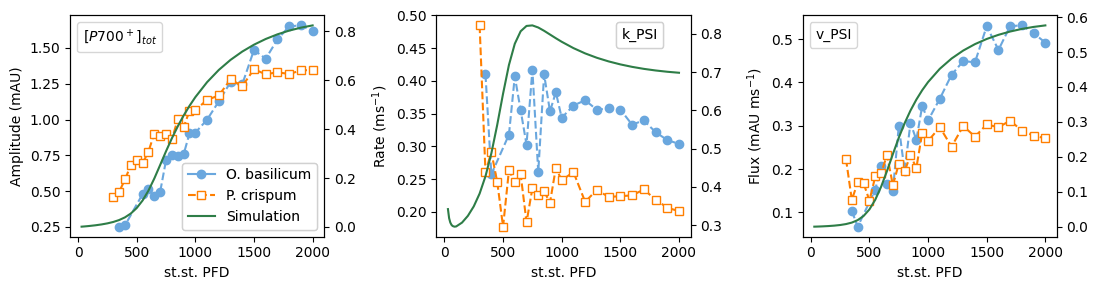

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(11, 3), sharex=True)
ax11 = ax1.twinx()
ax21 = ax2.twinx()
ax31 = ax3.twinx()

# Plot amplitude
ax1.plot(res_filt1['PAR'], res_filt1['amplitude'], color=colors[0], marker="o", linestyle="--", label="O. basilicum")
ax1.plot(res_filt2['PAR'], res_filt2['amplitude'], color=colors[1], marker="s", linestyle="--", label="P. crispum", markerfacecolor='white')
ax11.plot(simulated['PAR'], simulated['amplitude'], color=colors[2], linestyle="-", label="Simulation", markerfacecolor='white')
ax1.set_ylabel("Amplitude (mAU)")
ax1.set_xlabel("st.st. PFD")
#ax1.grid()
#label1 = Line2D([], [], color='none', label=r"$\Delta \psi_{\mathrm{tot}}$")
label1 = Line2D([], [], color='none', label=r"$[P700^+]_{tot}$")
ax1.add_artist(ax1.legend(handles=[label1], loc="upper left", handlelength=0, handletextpad=0))

# Plot rate
ax2.plot(res_filt1['PAR'], res_filt1['rate'], color=colors[0], marker="o", linestyle="--", label="O. basilicum")
ax2.plot(res_filt2['PAR'], res_filt2['rate'], color=colors[1], marker="s", linestyle="--", label="P. crispum", markerfacecolor='white')
ax21.plot(simulated['PAR'], simulated['rate'], color=colors[2], linestyle="-", label="Simulation")
ax2.set_ylabel("Rate (ms$^{-1}$)")
ax2.set_xlabel("st.st. PFD")
#ax2.grid()
# label2 = Line2D([], [], color='none', label=r"$g_{\mathrm{H}^+}$")
label2 = Line2D([], [], color='none', label=r"k_PSI")
ax2.add_artist(ax2.legend(handles=[label2], loc="upper center", bbox_to_anchor = (0.8,1), handlelength=0, handletextpad=0))

# Plot flux
ax3.plot(res_filt1['PAR'], res_filt1['flux'], color=colors[0], marker="o", linestyle="--", label="O. basilicum")
ax3.plot(res_filt2['PAR'], res_filt2['flux'], color=colors[1], marker="s", linestyle="--", label="P. crispum", markerfacecolor='white')
ax31.plot(simulated['PAR'], simulated['flux'], color=colors[2], linestyle="-", label="Simulation")
ax3.set_ylabel("Flux (mAU ms$^{-1}$)")
ax3.set_xlabel("st.st. PFD")
#ax3.grid()
# label3 = Line2D([], [], color='none', label=r"$v_{\mathrm{H}^+}$")
label3 = Line2D([], [], color='none', label=r"v_PSI")
ax3.legend(handles=[label3], loc="upper left", handlelength=0, handletextpad=0)

# Single legend
species_handles  = [
    Line2D([0], [0], label="O. basilicum", color=colors[0], marker="o", linestyle="-"),
    Line2D([0], [0], label="P. crispum",   color=colors[1], marker="s", linestyle="--", markerfacecolor='white'),
    Line2D([0], [0], label="Simulation",   color=colors[2], linestyle="-")
]
legend_species = ax1.legend(handles=species_handles, loc="lower right")

ax1.add_artist(legend_species)

fig.tight_layout()
fig.show()

In [11]:
save_fig(fig, "in_vivo", "analysis", f"in_vivo_analysis_P700_flux_rate_amplitude_three_plot")

saved figure to figures/in_vivo/analysis/in_vivo_analysis_P700_flux_rate_amplitude_three_plot.png


[(145.0, 200.0)]

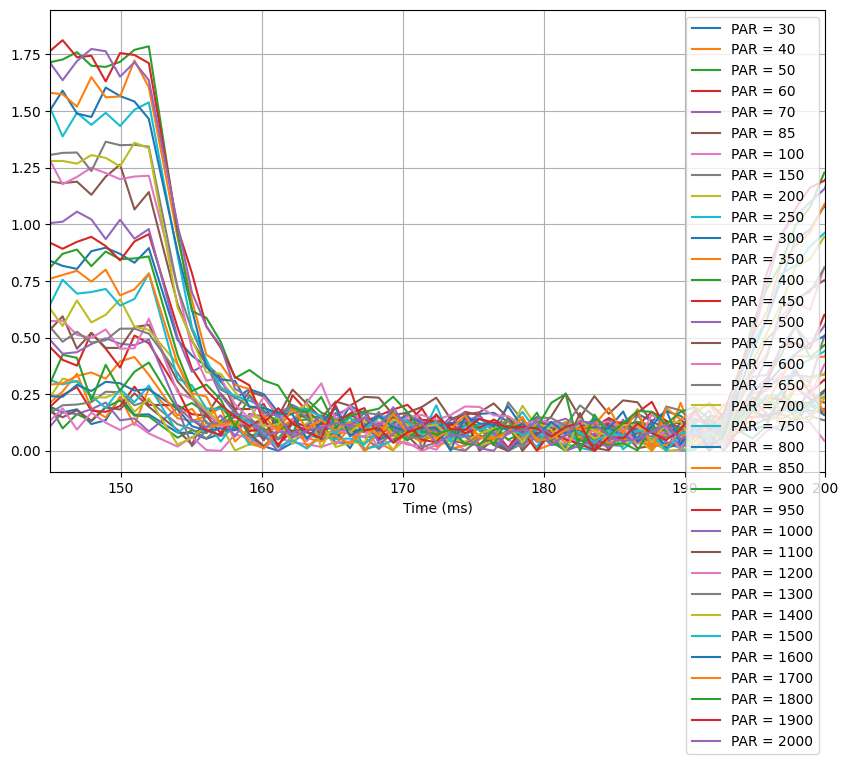

In [55]:
# plot all absorbances
fix, ax = plt.subplots(1,1, figsize = (10, 6))
for i,traces in enumerate(results1["traces"]):
    if True: #i == 21:#(i >= 10 and i <= 40):  
        trace = traces["absorbance"]
        trace_for_plotting= trace - min(trace)
        #trace_for_plotting = trace_for_plotting - min(trace_for_plotting)
        #trace_for_plotting = savgol_filter(trace_for_plotting, window_length=5, polyorder=4)
        ax.plot(trace_for_plotting, label=f'PAR = {results1["PAR"][i]}')
ax.set_xlabel('Time (ms)')
ax.grid()
ax.legend(loc='upper right')
ax.set(#yscale = "log",
       xlim = (145, 200),
       #ylim = (1e-2, 2)
       )

50


[np.float64(0.03554532111615119),
 np.float64(-0.10394868085817263),
 np.float64(24.999999999999996),
 np.float64(0.046579593684150766)]

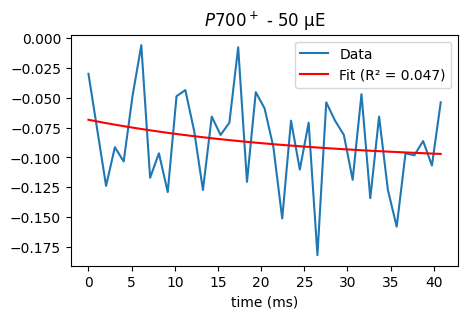

In [12]:
index = 2
pdseries = results1.traces[index]["fitting_input"]
PAR = results1.PAR[index]
print(PAR)
fit_function(pdseries.index, pdseries.values, exponential_decay,
             p0 = [1.5, -1.5, 5.6], bounds=([0, -np.inf, 0], [np.inf, 10, 25]),
             visualize= "all",
             #title=f'$\Delta \psi$ - {PAR} µE')
             title=f'$P700^+$ - {PAR} µE')

In [ ]:
# check for exponential dynamics!

# from scipy.signal import savgol_filter

def plot_log_trace(trace):
    smoothed = savgol_filter(trace, window_length=20, polyorder=3)
    #smoothed = trace
    for_log_plotting = smoothed - np.min(smoothed)
    for_log_plotting[for_log_plotting == 0] = np.nan
    for_log_plotting = for_log_plotting + 1e-4# add the asymptotic limit value if necessary
    plt.plot(for_log_plotting)
    plt.yscale('log')

for i in range(len(results["traces"])):
    plot_log_trace(results["traces"].iloc[i,]["fitting_input"])
    plt.title(f"Logarithmic plot of absorbance trace {i}")
    plt.show()